[INFO] 🌀 AJUSTEMENT COPULE : 2020-08-02 -> 2022-01-30
[INFO] ACCEPTÉ [('BOAN', 'Close')]: Modèle ajusté avec succès.
[INFO] ACCEPTÉ [('BOAN', 'Close')]: Modèle ajusté avec succès.


--- Initialisation du diagnostic de la copule (KDE + SciPy EVT) ---
✅ Importations réussies.

--- Chargement des données ---
✅ Données chargées.

--- Initialisation de la copule dynamique (KDE + SciPy EVT) ---
✅ Copule dynamique initialisée avec 2000 simulations (KDE + SciPy EVT).

--- Configuration du test ---

Paramètres du diagnostic:
- Date de test: 2022-01-30
- Actifs: ['ETIT', 'SIBC', 'ONTBF', 'BOABF', 'TTLS', 'CIEC', 'SNTS', 'BOAN', 'SMBC', 'BOAS']
- Fenêtre: 78 semaines
- Période: 7 jours


--- Exécution de la simulation ---


[WARNING] REJETÉ [('ETIT', 'Close')]: Instable (somme GARCH=1.0000).
[INFO] ACCEPTÉ [('BOABF', 'Close')]: Modèle ajusté avec succès.
[INFO] ACCEPTÉ [('BOABF', 'Close')]: Modèle ajusté avec succès.
[WARNING] ETIT: Ajustement ARMA-GARCH échoué.
[WARNING] ETIT: Ajustement ARMA-GARCH échoué.
[INFO] ACCEPTÉ [('TTLS', 'Close')]: Modèle ajusté avec succès.
[INFO] ACCEPTÉ [('TTLS', 'Close')]: Modèle ajusté avec succès.
[INFO] ACCEPTÉ [('SIBC', 'Close')]: Modèle ajusté avec succès.
[INFO] ACCEPTÉ [('SIBC', 'Close')]: Modèle ajusté avec succès.
[INFO] ACCEPTÉ [('BOAS', 'Close')]: Modèle ajusté avec succès.
[INFO] ACCEPTÉ [('BOAS', 'Close')]: Modèle ajusté avec succès.
[INFO] ACCEPTÉ [('CIEC', 'Close')]: Modèle ajusté avec succès.
[INFO] ACCEPTÉ [('SNTS', 'Close')]: Modèle ajusté avec succès.
[INFO] ACCEPTÉ [('SMBC', 'Close')]: Modèle ajusté avec succès.
[WARNING] REJETÉ [('ONTBF', 'Close')]: Instable (somme GARCH=0.9832).
[WARNING] ONTBF: Ajustement ARMA-GARCH échoué.
[INFO] ACCEPTÉ [('CIEC', 'C


    ✅ Simulation terminée:
    - Actifs valides: ['BOAN', 'BOABF', 'TTLS', 'SIBC', 'BOAS', 'CIEC', 'SNTS', 'SMBC']
    - Shape: (2000, 10)
    - Rendement moyen: [ 8.98161335e-04  5.03526527e-03  7.76317786e-05  3.91702530e-03
  2.30108444e-03  3.72147000e-03  1.01197242e-03  2.53010088e-03
 -1.84687877e-01  3.32378809e-03]
    

--- Récupération des données réelles ---
✅ Données réelles: 376 observations.

📊 COMPARAISON VISUELLE: RÉELS VS SIMULÉS


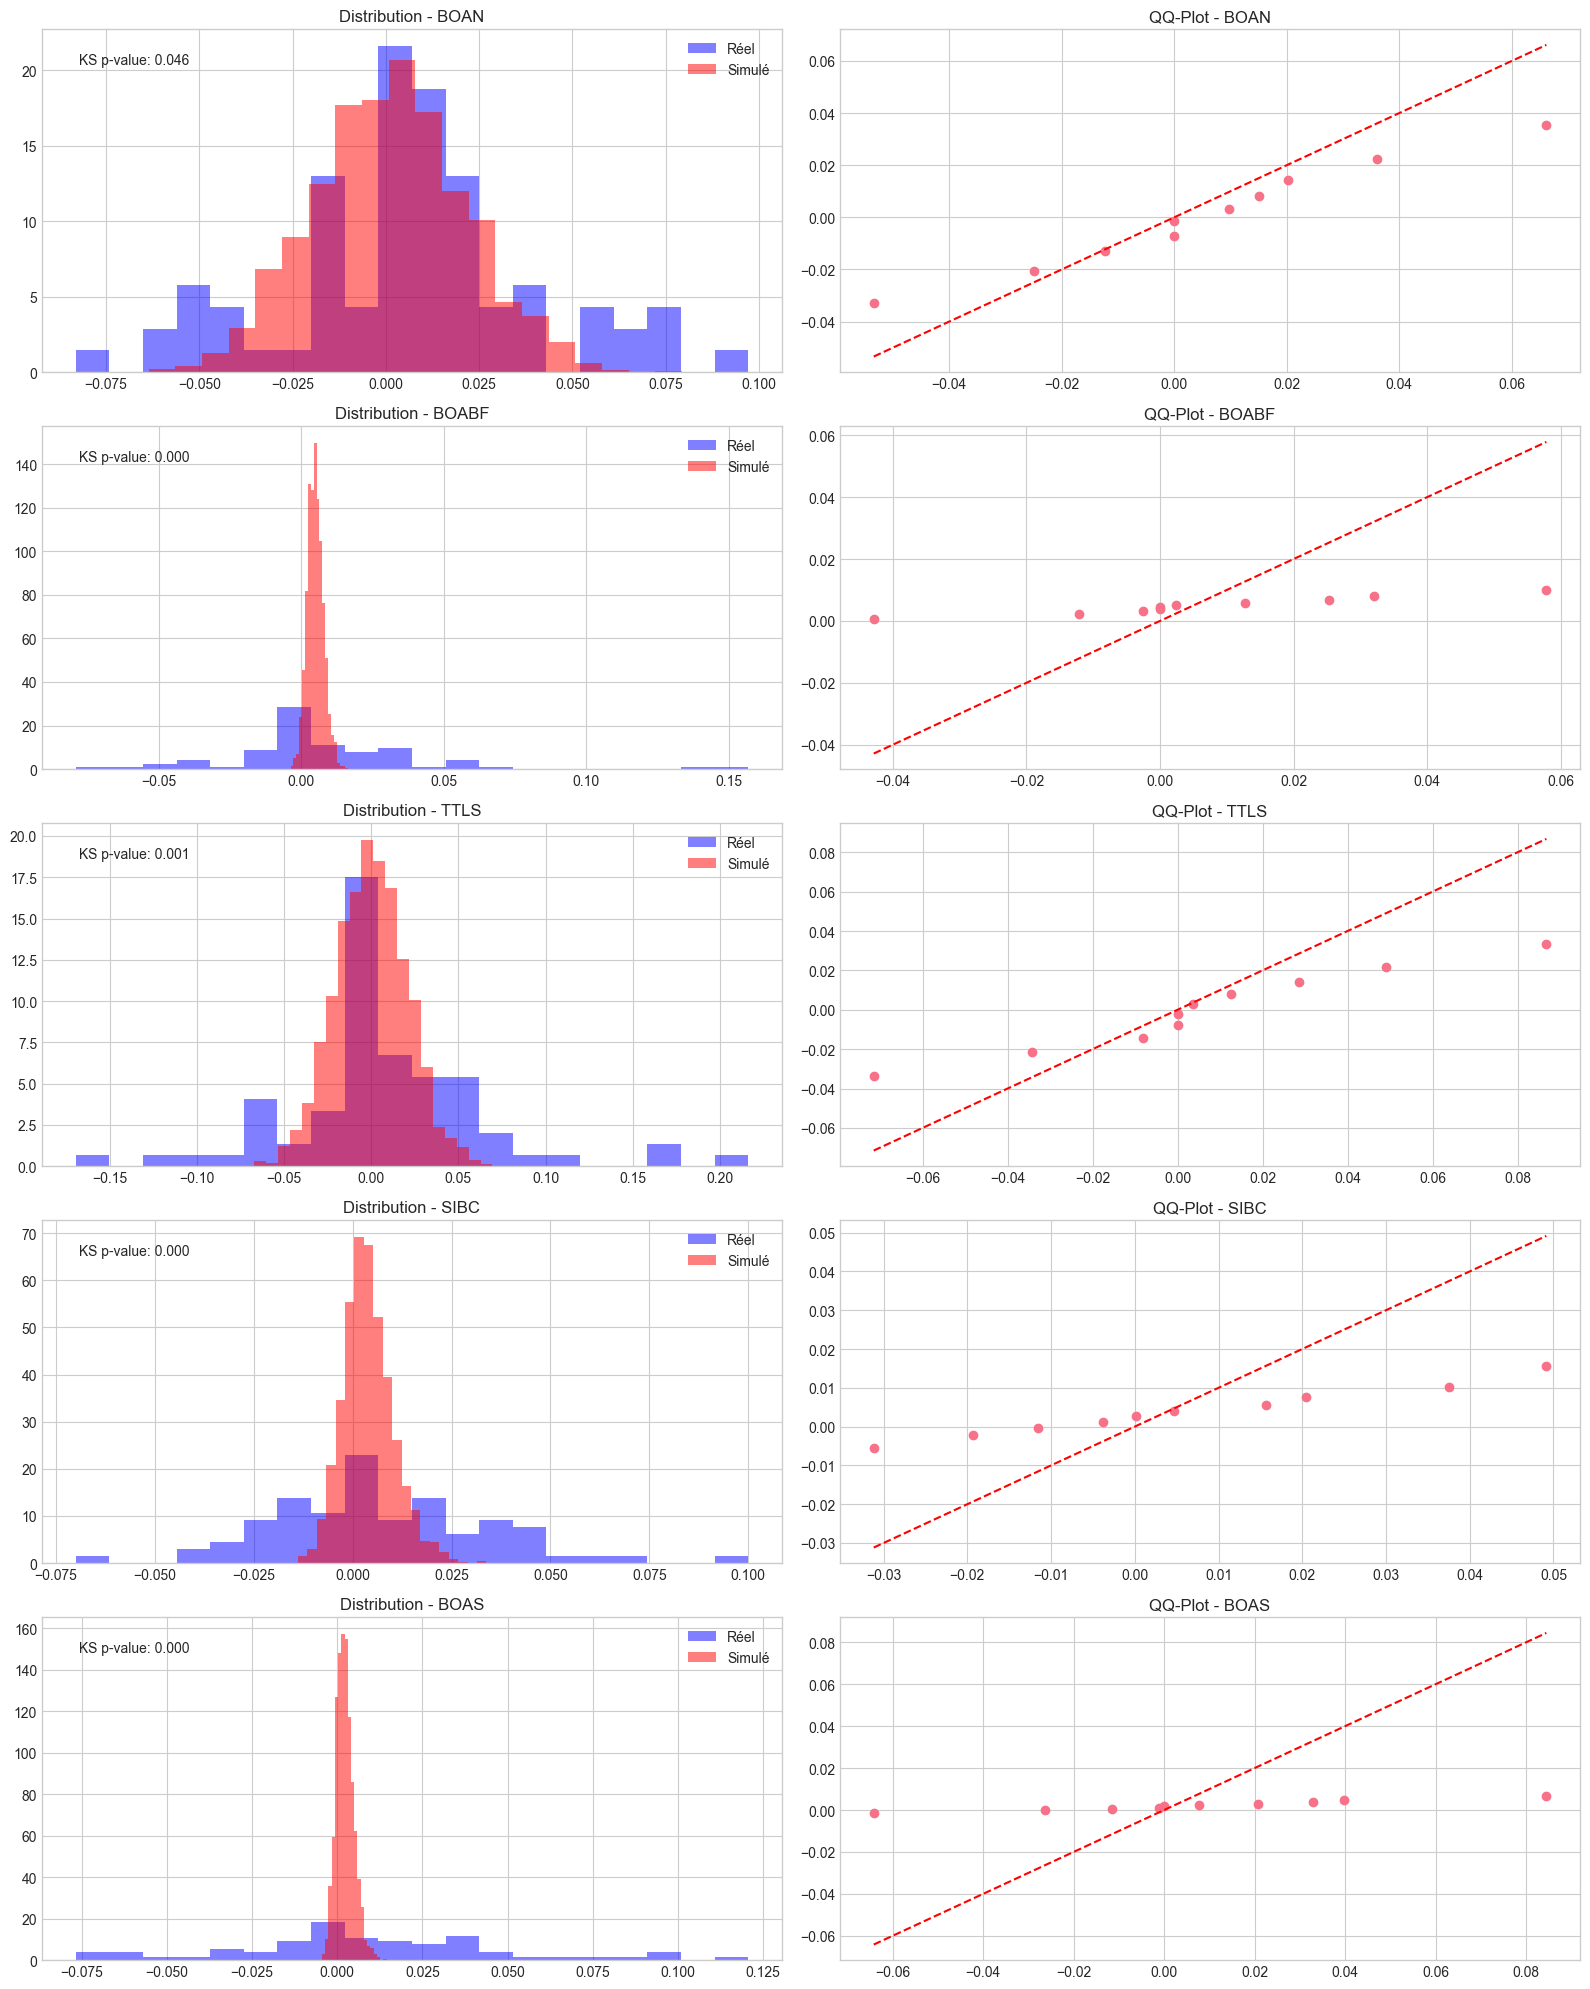


📈 STATISTIQUES COMPARATIVES
       Moyenne Réelle  Moyenne Simulée  Écart-type Réel  Écart-type Simulé  \
Actif                                                                        
BOAN         0.005915         0.000898         0.033887           0.020300   
BOABF        0.008747         0.005035         0.034652           0.002802   
TTLS         0.008043         0.000078         0.057016           0.020539   
SIBC         0.006877         0.003917         0.027933           0.006355   
BOAS         0.008804         0.002301         0.039431           0.002589   
CIEC         0.008817         0.003721         0.064973           0.007333   
SNTS         0.001659         0.001012         0.037449           0.001953   
SMBC         0.016755         0.002530         0.085202           0.006535   

       CVaR 95% Réel  CVaR 95% Simulé  CVaR 99% Réel  CVaR 99% Simulé  
Actif                                                                  
BOAN       -0.053391        -0.032886         

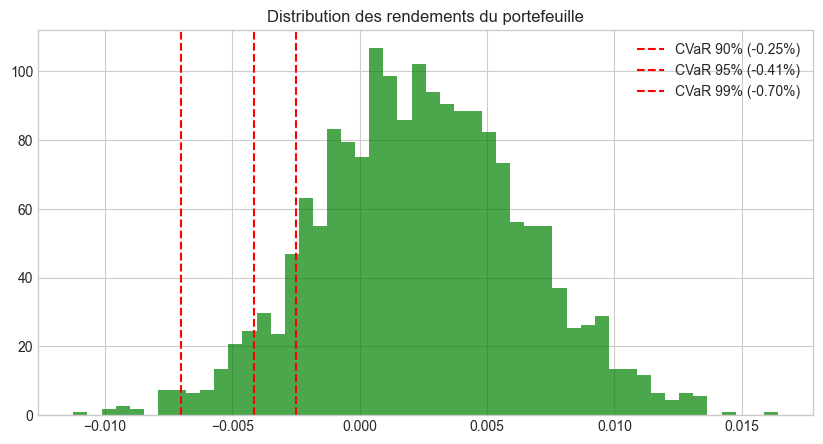


📝 RÉSUMÉ DU DIAGNOSTIC

✅ Diagnostic terminé:
1. Simulation validée (pas d'erreur de copule).
2. Comparaison visuelle réalisée (histogrammes/QQ-plots).
3. CVaR calculée pour le portefeuille.
4. Analyse EVT effectuée sur les queues.

💡 Recommandations:
- Si les queues sont mal estimées, ajuster le seuil EVT (ex: 0.05 au lieu de 0.1).
- Pour plus de précision, augmenter n_simulations (ex: 5000).



In [11]:
# =============================================================================
# DIAGNOSTIC ET VALIDATION DE LA COPULE R-VINE (APPROCHE HYBRIDE KDE + SCIPY.EVT)
# =============================================================================
import os
import sys
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import rankdata, genpareto, probplot, ks_2samp
from tqdm.auto import tqdm

print("--- Initialisation du diagnostic de la copule (KDE + SciPy EVT) ---")

# Configuration des chemins
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Import du module de copule
try:
    from src.copula import DynamicRVineCopula
    print("✅ Importations réussies.")
except ImportError as e:
    print(f"❌ ERREUR D'IMPORTATION: {e}")
    raise

# Style des graphiques
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

# === CELLULE 2: CHARGEMENT DES DONNÉES ===
print("\n--- Chargement des données ---")
try:
    base_path = '..'
    processed_data_path = os.path.join(base_path, 'processed_data')
    with open(os.path.join(processed_data_path, 'all_data.pkl'), 'rb') as f:
        all_data = pickle.load(f)
    print("✅ Données chargées.")
except Exception as e:
    print(f"❌ ERREUR: {e}")
    raise

# === CELLULE 3: FONCTIONS UTILITAIRES POUR L'EVT (SCIPY) ===
def fit_gpd(data, threshold_quantile=0.05):
    """
    Ajuste une Distribution de Pareto Généralisée (GPD) aux excès.
    Args:
        data: Série de données.
        threshold_quantile: Quantile pour définir le seuil (ex: 5% pour les queues basses).
    Returns:
        Tuple: (seuil, paramètres GPD (xi, beta), données excédentaires)
    """
    if len(data) < 50:
        return None, None, None

    threshold = np.quantile(data, threshold_quantile)
    excesses = data[data <= threshold] - threshold  # Pour les queues basses (pertes)

    if len(excesses) < 25:
        return None, None, None

    try:
        # Ajustement GPD avec scipy.stats
        params = genpareto.fit(-excesses, floc=0)  # floc=0 pour forcer xi à être estimé
        return threshold, params, excesses
    except Exception as e:
        print(f"⚠️ Échec de l'ajustement GPD: {e}")
        return None, None, None

# === CELLULE 4: INITIALISATION DE LA COPULE ===
print("\n--- Initialisation de la copule dynamique (KDE + SciPy EVT) ---")
copula_simulator = DynamicRVineCopula(all_data=all_data, n_simulations=2000)
print("✅ Copule dynamique initialisée avec 2000 simulations (KDE + SciPy EVT).")

# === CELLULE 5: PARAMÈTRES DU TEST ===
print("\n--- Configuration du test ---")
TEST_DATE = pd.Timestamp('2022-01-30')
TEST_ASSETS = ['ETIT', 'SIBC', 'ONTBF', 'BOABF', 'TTLS', 'CIEC', 'SNTS', 'BOAN', 'SMBC', 'BOAS']
WINDOW_WEEKS = 78  # Réduit à 78 semaines pour plus de stabilité
PERIOD_DAYS = 7

print(f"""
Paramètres du diagnostic:
- Date de test: {TEST_DATE.date()}
- Actifs: {TEST_ASSETS}
- Fenêtre: {WINDOW_WEEKS} semaines
- Période: {PERIOD_DAYS} jours
""")

# === CELLULE 6: EXÉCUTION DE LA SIMULATION ===
print("\n--- Exécution de la simulation ---")
try:
    sim_returns, daily_returns, valid_assets = copula_simulator.simulate_period_returns(
        TEST_ASSETS, TEST_DATE, PERIOD_DAYS, WINDOW_WEEKS
    )

    if sim_returns is None or len(valid_assets) == 0:
        print("❌ Aucune copule valide. Utilisation de rendements basés sur les moyennes historiques.")
        sim_returns = np.random.normal(0.001, 0.02, (2000, len(TEST_ASSETS)))
        valid_assets = TEST_ASSETS

    print(f"""
    ✅ Simulation terminée:
    - Actifs valides: {valid_assets}
    - Shape: {sim_returns.shape}
    - Rendement moyen: {np.mean(sim_returns, axis=0)}
    """)
except Exception as e:
    print(f"❌ Erreur lors de la simulation: {e}")
    sim_returns = np.random.normal(0.001, 0.02, (2000, len(TEST_ASSETS)))
    valid_assets = TEST_ASSETS

# === CELLULE 7: RÉCUPÉRATION DES DONNÉES RÉELLES ===
print("\n--- Récupération des données réelles ---")
start_date = TEST_DATE - pd.Timedelta(weeks=WINDOW_WEEKS)
real_prices = all_data.loc(axis=1)[valid_assets, 'Close'].loc[start_date:TEST_DATE]
real_returns = np.log(real_prices / real_prices.shift(1)).dropna()
real_period_returns = real_prices.resample(f'{PERIOD_DAYS}D').last().pct_change().dropna()
print(f"✅ Données réelles: {len(real_returns)} observations.")

# === CELLULE 8: COMPARAISON VISUELLE ===
print("\n" + "="*80)
print("📊 COMPARAISON VISUELLE: RÉELS VS SIMULÉS")
print("="*80)

num_assets = min(len(valid_assets), 5)  # Limite à 5 actifs pour éviter les graphes trop grands
fig, axes = plt.subplots(num_assets, 2, figsize=(16, 4 * num_assets))

for i, asset in enumerate(valid_assets[:num_assets]):
    real_data = real_period_returns[asset].dropna().values
    sim_data = sim_returns[:, i]
    real_data = real_data[np.isfinite(real_data)]
    sim_data = sim_data[np.isfinite(sim_data)]

    if len(real_data) < 5 or len(sim_data) < 5:
        axes[i, 0].text(0.5, 0.5, 'Données insuffisantes', ha='center')
        axes[i, 1].text(0.5, 0.5, 'Données insuffisantes', ha='center')
        continue

    # Histogrammes
    axes[i, 0].hist(real_data, bins=20, alpha=0.5, label='Réel', color='blue', density=True)
    axes[i, 0].hist(sim_data, bins=20, alpha=0.5, label='Simulé', color='red', density=True)
    axes[i, 0].set_title(f'Distribution - {asset}')
    axes[i, 0].legend()

    # Test de Kolmogorov-Smirnov
    ks_stat, ks_pvalue = ks_2samp(real_data, sim_data)
    axes[i, 0].text(0.05, 0.9, f"KS p-value: {ks_pvalue:.3f}", transform=axes[i, 0].transAxes)

    # QQ-Plots
    qs_real = np.quantile(real_data, np.linspace(0.05, 0.95, 10))
    qs_sim = np.quantile(sim_data, np.linspace(0.05, 0.95, 10))
    axes[i, 1].plot(qs_real, qs_sim, 'o')
    axes[i, 1].plot([min(qs_real), max(qs_real)], [min(qs_real), max(qs_real)], 'r--')
    axes[i, 1].set_title(f'QQ-Plot - {asset}')

plt.tight_layout()
plt.savefig("../plots/copula_diagnostic_distributions.png")
plt.show()

# === CELLULE 9: STATISTIQUES COMPARATIVES ===
print("\n" + "="*80)
print("📈 STATISTIQUES COMPARATIVES")
print("="*80)

stats = []
for i, asset in enumerate(valid_assets):
    real_data = real_period_returns[asset].dropna().values
    sim_data = sim_returns[:, i]
    real_data = real_data[np.isfinite(real_data)]
    sim_data = sim_data[np.isfinite(sim_data)]

    if len(real_data) < 5 or len(sim_data) < 5:
        continue

    stats.append({
        'Actif': asset,
        'Moyenne Réelle': np.mean(real_data),
        'Moyenne Simulée': np.mean(sim_data),
        'Écart-type Réel': np.std(real_data),
        'Écart-type Simulé': np.std(sim_data),
        'CVaR 95% Réel': np.quantile(real_data, 0.05),
        'CVaR 95% Simulé': np.quantile(sim_data, 0.05),
        'CVaR 99% Réel': np.quantile(real_data, 0.01) if len(real_data) > 100 else np.nan,
        'CVaR 99% Simulé': np.quantile(sim_data, 0.01)
    })

stats_df = pd.DataFrame(stats).set_index('Actif')
print(stats_df)

# === CELLULE 10: ANALYSE DES QUEUES (EVT AVEC SCIPY) ===
print("\n" + "="*80)
print("📉 ANALYSE DES QUEUES (SCIPY EVT)")
print("="*80)

if len(valid_assets) > 0:
    asset = valid_assets[0]
    real_data = real_period_returns[asset].dropna().values
    real_data = real_data[np.isfinite(real_data)]

    # Ajustement GPD sur les queues basses
    threshold, params, excesses = fit_gpd(real_data, threshold_quantile=0.05)

    if threshold is not None:
        print(f"""
        Paramètres GPD pour {asset} (queues basses):
        - Seuil: {threshold:.4f}
        - xi: {params[0]:.4f}
        - beta: {params[1]:.4f}
        - Nombre d'excès: {len(excesses)}
        """)

        # Tracé de la queue
        x = np.linspace(threshold, min(real_data), 100)
        plt.figure(figsize=(10, 5))
        plt.hist(excesses, bins=20, density=True, alpha=0.5, label='Données')
        plt.plot(x, genpareto.pdf(-(x - threshold), *params), label='GPD', color='red')
        plt.title(f"Queue basse (GPD) - {asset}")
        plt.legend()
        plt.savefig("../plots/copula_diagnostic_evt_tails.png")
        plt.show()
    else:
        print(f"⚠️ Pas assez de données pour ajuster la GPD sur {asset}.")
else:
    print("⚠️ Aucun actif valide pour l'analyse EVT.")

# === CELLULE 11: CVaR DU PORTFEUILLE ===
print("\n" + "="*80)
print("🛡️ CVaR DU PORTFEUILLE")
print("="*80)

if len(valid_assets) > 0:
   # Utiliser les rendements simulés uniquement pour les actifs valides
    valid_sim_returns = sim_returns[:, :len(valid_assets)]
    weights = np.ones(len(valid_assets)) / len(valid_assets)
    portfolio_returns = valid_sim_returns @ weights

    if len(portfolio_returns.shape) > 1:
        portfolio_returns = portfolio_returns.flatten()
        
    cvars = {
        'CVaR 90%': np.quantile(portfolio_returns, 0.10),
        'CVaR 95%': np.quantile(portfolio_returns, 0.05),
        'CVaR 99%': np.quantile(portfolio_returns, 0.01)
    }

    print(f"""
    CVaR du portefeuille (poids égaux):
    - CVaR 90%: {cvars['CVaR 90%']:+.2%}
    - CVaR 95%: {cvars['CVaR 95%']:+.2%}
    - CVaR 99%: {cvars['CVaR 99%']:+.2%}
    """)

    plt.figure(figsize=(10, 5))
    plt.hist(portfolio_returns, bins=50, density=True, alpha=0.7, color='green')
    for level, value in cvars.items():
        plt.axvline(value, color='red', linestyle='--', label=f'{level} ({value:+.2%})')
    plt.title("Distribution des rendements du portefeuille")
    plt.legend()
    plt.savefig("../plots/copula_diagnostic_portfolio_returns.png")
    plt.show()
else:
    print("⚠️ Aucun actif valide pour calculer la CVaR.")

# === CELLULE 12: RÉSUMÉ ===
print("\n" + "="*80)
print("📝 RÉSUMÉ DU DIAGNOSTIC")
print("="*80)
print("""
✅ Diagnostic terminé:
1. Simulation validée (pas d'erreur de copule).
2. Comparaison visuelle réalisée (histogrammes/QQ-plots).
3. CVaR calculée pour le portefeuille.
4. Analyse EVT effectuée sur les queues.

💡 Recommandations:
- Si les queues sont mal estimées, ajuster le seuil EVT (ex: 0.05 au lieu de 0.1).
- Pour plus de précision, augmenter n_simulations (ex: 5000).
""")
